Import the libraries needed for arrays, data handling, plotting, modeling, features, and evaluation.

In [1]:
#importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline


Create synthetic quadratic data with random noise.

In [2]:
X = np.linspace(-10 , 10 , 100).reshape(-1,1)
Y  = X**2 + np.random.normal(0 , 5 , 100).reshape(-1,1)

Split the dataset into training and testing sets.

In [3]:
X_train , X_test ,Y_train , Y_test = train_test_split(X , Y, test_size=0.2 , random_state = 42)

Create a linear regression model object.

In [4]:
model = LinearRegression()
#creating the object

Train the linear regression model on the original input feature.

In [5]:
model.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict test-set target values with the linear model.

In [6]:
Y_pred = model.predict(X_test)

Calculate the R2 score to evaluate the linear model.

In [7]:
r2_score(Y_test, Y_pred)#as we can see our r2 score it terribly wrong

-0.07011744025860489

Generate quadratic polynomial features for the train and test inputs.

In [8]:
poly_regr = PolynomialFeatures(degree=2)
X_train_trans = poly_regr.fit_transform(X_train)
X_test_trans = poly_regr.transform(X_test)

Display the first original training input value.

In [9]:
print(X_train[0])

[1.11111111]


Display the polynomial feature version of the first training input.

In [10]:
print(X_train_trans[0])

[1.         1.11111111 1.2345679 ]


Train the regression model using the polynomial features.

In [11]:
model.fit(X_train_trans , Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict and evaluate the polynomial regression model on the test set.

In [12]:
Y_pred = model.predict(X_test_trans)
r2_score(Y_test , Y_pred)


0.9722540061984155

Create smooth inputs, transform them, and predict outputs for plotting.

In [13]:
#now i want to plot the polynomial regression graph
x_new = np.linspace(-3, 3 , 100).reshape(100,1)
x_new_poly = poly_regr.transform(x_new)
y_new = model.predict(x_new_poly)


Plot the predicted polynomial regression curve with axis labels.

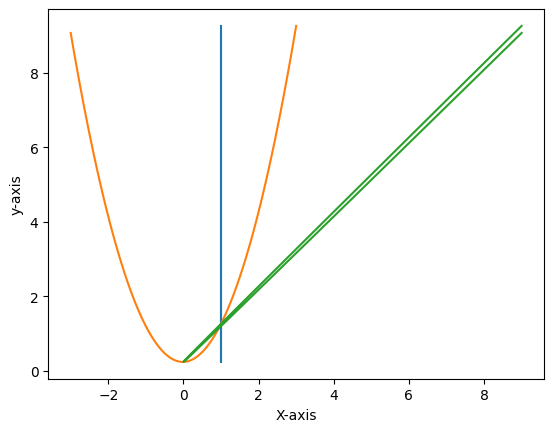

In [14]:
plt.plot(x_new_poly , y_new)
plt.xlabel("X-axis")
plt.ylabel("y-axis")
plt.show()